In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import itertools

# For visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Import the necessary libraries
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB


: 

In [ ]:
# Load the dataset
df = pd.read_csv("data/creditcard.csv")

# Describing the data
# print("The dataframe can be described as:")
# df.describe()

In [ ]:
# Finding null values
# print("The null-values within the dataframe are: ", df.isnull().sum())

In [ ]:
# Finding NA values
# print("The N/A values within the dataframe are: ", df.isna().sum())

In [ ]:
# Visualize the class label distribution
# sns.countplot(x='Class', data=df)
# plt.title("Class Label Distribution")
# plt.show()

# Visualize the transactions amount distribution
# sns.distplot(df['Amount'], kde=False)
# plt.title("Transactions Amount Distribution")
# plt.show()

In [ ]:
# Heatmap of Feature Correlations
# plt.figure(figsize=(40, 20))
# sns.heatmap(df.corr(), annot=True, cmap='rocket', square=True, fmt='.2f', linewidths=0.5)
# plt.title("Heatmap of Feature Correlations")
# plt.show()

In [ ]:
# Transaction times
# plt.figure(figsize=(10, 6))
# sns.histplot(df['Time'], bins=50, kde=False)
# plt.title("Transaction Times Histogram")
# plt.xlabel("Time (in seconds)")
# plt.ylabel("Count")
# plt.show()

In [ ]:
# Box plot of transaction amounts for each class
# plt.figure(figsize=(8, 6))
# sns.boxplot(x='Class', y='Amount', data=df)
# plt.title("Box Plot of Transaction Amounts for Each Class")
# plt.xlabel("Class (0: Non-Fraudulent, 1: Fraudulent)")
# plt.ylabel("Transaction Amount")
# plt.show()

In [ ]:
# Preprocessing steps

# From the boxplot above we can say that its best to remove non-fraudulent data wherein its amount exceed the
# maximum amount of fraudulent transactions
max_fraud_amount = df.loc[df['Class']==1,"Amount"].max()
df = df[df["Amount"]<=max_fraud_amount]

# Create a boxplot to confirm
# plt.figure(figsize=(8, 6))
# sns.boxplot(x='Class', y='Amount', data=df)
# plt.title("Box Plot of Transaction Amounts after filtering for Each Class")
# plt.xlabel("Class (0: Non-Fraudulent, 1: Fraudulent)")
# plt.ylabel("Transaction Amount")
# plt.show()

# Droppping the Time column
df = df.drop(["Time"], axis=1)

# Transforming the Amount column
scaler = StandardScaler()
df["Amount"] = scaler.fit_transform(df["Amount"].values.reshape(-1, 1))

In [ ]:
# Split data into features and labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Feature distribution of each class
df_fraud = df[df['Class'] == 1]
df_non_fraud = df[df['Class'] == 0]

In [ ]:
# plt.figure(figsize=(15, 20))
# for i, col in enumerate(df.columns[:-1], 1):
#     plt.subplot(6, 5, i)
#     sns.kdeplot(data=df_non_fraud, x=col, fill=True, color='blue', label='Non-Fraudulent')
#     sns.kdeplot(data=df_fraud, x=col, fill=True, color='red', label='Fraudulent')
#     plt.xlabel(col)
#     plt.ylabel('Density')
#     plt.legend()
# plt.tight_layout()
# plt.show()

In [ ]:
# Equalize the number of fraudulent and non-fraudulent transactions within the dataframe

minority_count = df[df['Class'] == 1].shape[0]
majority_count = df[df['Class'] == 0].shape[0]

total_desired_rows = 284807
desired_minority_count = total_desired_rows // 2
desired_majority_count = total_desired_rows // 2

smote = SMOTE(sampling_strategy={1: desired_minority_count})
under = RandomUnderSampler(sampling_strategy={0: desired_majority_count})
pipeline = Pipeline(steps=[('s', smote), ('u', under)])
X_new, y_new = pipeline.fit_resample(X, y) 

# column_names = df.columns[:-1]
# X_new_df = pd.DataFrame(X_new, columns=column_names)
# y_new_df = pd.DataFrame(y_new, columns=['Class'])
# df_new = pd.concat([X_new_df, y_new_df], axis=1)


In [ ]:
# Create a boxplot to confirm equal distribution
# plt.figure(figsize=(8, 6))
# sns.countplot(x='Class', data=df_new, palette=['blue','red'])
# plt.title("Box Plot of Transaction Amounts after filtering for Each Class")
# plt.xlabel("Class (0: Non-Fraudulent, 1: Fraudulent)")
# plt.ylabel("Transaction Amount")
# plt.show()

In [ ]:
# # Calculating the rows and columns for grid subplots.
# import math
# 
# # Calculate the number of rows and columns for the grid
# num_features = len(df_new.columns) - 1
# num_cols = 5
# num_rows = math.ceil(num_features / num_cols)
# 
# # Create the grid of subplots
# fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 4))
# fig.tight_layout(pad=5.0)
# 
# # Boxplot distribution for fraudulent and non-fraudulent transactions for each feature
# for idx, column in enumerate(df_new.columns[:-1]):
#     row = idx // num_cols
#     col = idx % num_cols
#     sns.boxplot(x="Class", y=column, data=df_new, ax=axes[row, col])
#     axes[row, col].set_title(f"Boxplot of {column} by Class")
# plt.title(f"Box plot of {column} by Class")
# plt.show()
# 
# for idx in range(num_features, num_rows * num_cols):
#     row = idx // num_cols
#     col = idx % num_cols
#     axes[row, col].axis("off")

In [ ]:
# # Heatmap of Feature Correlations with the new dataframe
# plt.figure(figsize=(40, 20))
# sns.heatmap(df_new.corr(), annot=True, cmap='rocket', square=True, fmt='.2f', linewidths=0.5)
# plt.title("Heatmap of Feature Correlations with the new dataframe")
# plt.show()

In [ ]:
# Adding Logistic-Regression, KNN, Decision Tree, Naive Bayes and Random Forest classifiers
classifiers = {
    # "Logistic Regression": LogisticRegression(),
    # "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    # "Naive Bayes": GaussianNB()
}

# Create a Multiple attention layer
class Multi_Attention(nn.Module):
    def __init__(self, samp_model, num_heads):
        super(Multi_Attention, self).__init__()
        assert samp_model % num_heads == 0

        self.samp_model = samp_model
        self.num_heads = num_heads
        self.count = samp_model // num_heads

        self.Wq = nn.Linear(samp_model, samp_model)
        self.Wk = nn.Linear(samp_model, samp_model)
        self.Wv = nn.Linear(samp_model, samp_model)
        self.Wo = nn.Linear(samp_model, samp_model)

    def forward(self, x):
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        Q, K, V = self.split_heads(Q, K, V)

        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.count)
        attention_weights = torch.softmax(scores, dim=-1)
        attended_values = torch.matmul(attention_weights, V)
        attended_values = self.combine_heads(attended_values)

        return self.Wo(attended_values).squeeze(1)

    def split_heads(self, Q, K, V):
        batch_size = Q.size(0)
        Q = Q.view(batch_size, -1, self.num_heads, self.count).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.count).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.count).transpose(1, 2)
        return Q, K, V

    def combine_heads(self, attended_values):
        batch_size = attended_values.size(0)
        return attended_values.transpose(1, 2).contiguous().view(batch_size, -1, self.samp_model)

# Create the model
class CreditCardFraudModel(nn.Module):
    def __init__(self, input_size, dropout_prob=0.5):
        super(CreditCardFraudModel, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.BatchNorm1d(128)
        )

        self.multi_attention = Multi_Attention(128, 2)
        self.layer2 = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.BatchNorm1d(64)
        )

        self.layer3 = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.BatchNorm1d(32),
        )
        self.output_layer = nn.Linear(32, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.multi_attention(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.output_layer(x)
        return torch.sigmoid(x)

# Plotting confusion matrix
def plot_confusion_matrix(ax, conf_mat, split, name):
    im = ax.imshow(conf_mat, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(f'{name} (Split {split})')
    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(['Non-Fraud', 'Fraud'], rotation=45)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(['Non-Fraud', 'Fraud'])
    thresh = conf_mat.max() / 2.
    for i, j in itertools.product(range(conf_mat.shape[0]), range(conf_mat.shape[1])):
        ax.text(j, i, format(conf_mat[i, j], 'd'), horizontalalignment="center", color="white" if conf_mat[i, j] > thresh else "black")
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')

# Train and evaluate the model
def train_and_evaluate(model, train_loader, test_loader, num_epochs, optimizer, scheduler, criterion, device):
    model.train()

    for epoch in range(num_epochs):
        running_loss_avg = 0.0
        alpha = 0.1
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels.float())
            loss.backward()
            optimizer.step()

            if scheduler:
                scheduler.step()

            running_loss_avg = alpha * loss.item() + (1 - alpha) * running_loss_avg

        # print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss / len(train_loader):.4f}")

    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_pred.extend(outputs.squeeze().tolist())
            y_true.extend(labels.tolist())

    y_pred = np.array(y_pred)
    y_pred_labels = (y_pred >= 0.5).astype(int)

    # This is for accuracy
    correct = np.sum(y_true == y_pred_labels)
    total = len(y_true)
    accuracy = correct / total

    precision = precision_score(y_true, y_pred_labels)
    recall = recall_score(y_true, y_pred_labels)
    f1 = f1_score(y_true, y_pred_labels)
    roc_auc = roc_auc_score(y_true, y_pred)
    
    conf_mat = confusion_matrix(y_true, y_pred_labels)

    return precision, recall, f1, roc_auc, accuracy, conf_mat, running_loss_avg


C:\Users\Jason\AppData\Local\Temp\ipykernel_17456\3696472527.py:2: UserWarning: Failed to initialize NumPy: module compiled against API version 0x10 but this version of numpy is 0xf (Triggered internally at ..\torch\csrc\utils\tensor_numpy.cpp:77.)
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


cpu
This is Split number:  1


Decision Tree:
Accuracy: 0.9970, Precision: 0.9959, Recall: 0.9981, F1-score: 0.9970, ROC-AUC: 0.9970



For the CreditCardFraudModel:
Accuracy: 0.9980, Precision: 0.9993, Recall: 0.9967, F1-score: 0.9980, ROC-AUC: 0.9999


This is Split number:  2


Decision Tree:
Accuracy: 0.9971, Precision: 0.9961, Recall: 0.9982, F1-score: 0.9971, ROC-AUC: 0.9971



For the CreditCardFraudModel:
Accuracy: 0.8362, Precision: 0.9997, Recall: 0.6724, F1-score: 0.8040, ROC-AUC: 0.9998


This is Split number:  3


Decision Tree:
Accuracy: 0.9974, Precision: 0.9966, Recall: 0.9982, F1-score: 0.9974, ROC-AUC: 0.9974



For the CreditCardFraudModel:
Accuracy: 0.9736, Precision: 0.9996, Recall: 0.9475, F1-score: 0.9729, ROC-AUC: 0.9999


This is Split number:  4


Decision Tree:
Accuracy: 0.9972, Precision: 0.9962, Recall: 0.9981, F1-score: 0.9972, ROC-AUC: 0.9972



For the CreditCardFraudModel:
Accuracy: 0.9902, Precision: 0.9993, Recall: 0.9811, F1-score: 0.9901, ROC-AUC: 0

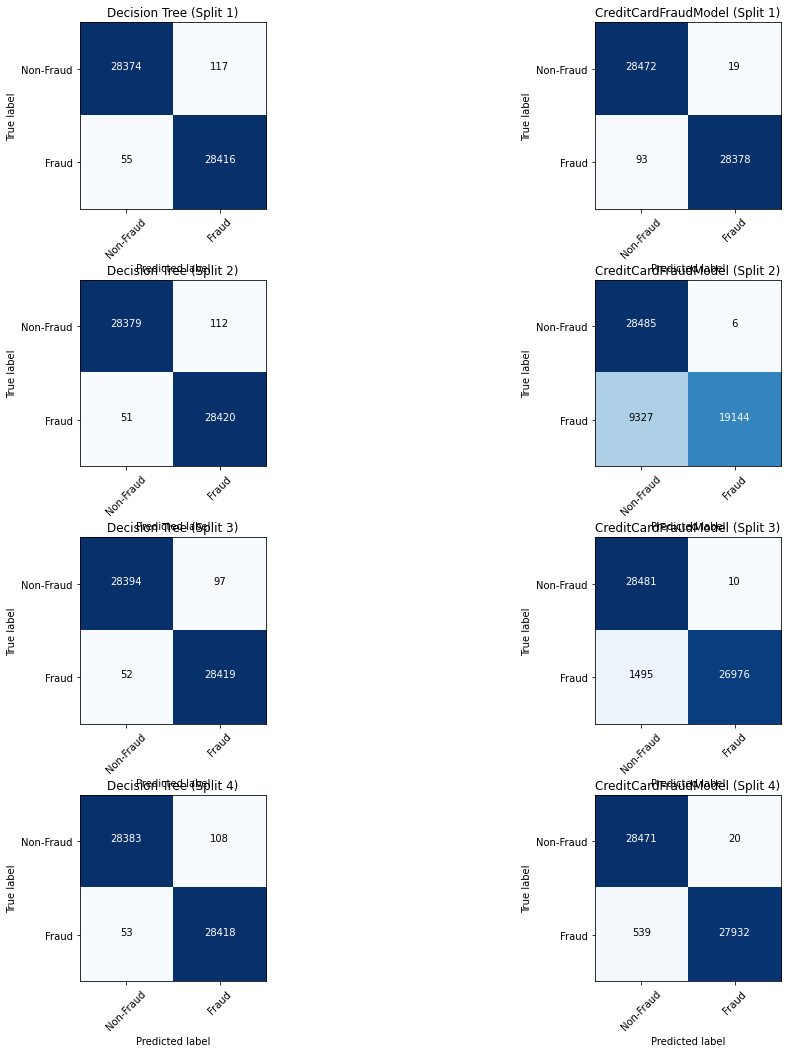

In [ ]:
# Main program
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
#  device = torch.device("cuda")
skf = StratifiedKFold(n_splits=4)
criterion = nn.BCELoss()

metrics = {}

for name in classifiers.keys():
    metrics[name] = {"accuracy": [], "loss": []}
    metrics["CreditCardFraudModel"] = {"accuracy": [], "loss": []}

num_splits = 4
num_classifiers = len(classifiers) + 1  # Add 1 for the CreditCardFraudModel
fig, axes = plt.subplots(num_splits, num_classifiers, figsize=(15, 15))
fig.tight_layout(pad=5.0)

counter=1

for train_index, test_index in skf.split(X_new, y_new):
    X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

    col_idx = 0

    print("This is Split number: ",counter)

    print("\n===========================================================================\n")

    for name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred)
        metrics[name]["accuracy"].append(accuracy)

        conf_mat = confusion_matrix(y_test, y_pred)
        plot_confusion_matrix(axes[counter - 1, col_idx], conf_mat, counter, name)
        col_idx += 1

        print(f"{name}:")
        print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}, ROC-AUC: {roc_auc:.4f}\n")

    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
    test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    model = CreditCardFraudModel(X_train.shape[1]).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
    num_epochs = 15
    num_train_steps = num_epochs * len(train_loader)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * num_train_steps), num_training_steps=num_train_steps)

    precision, recall, f1, roc_auc, accuracy, conf_mat, running_loss_avg = train_and_evaluate(model, train_loader, test_loader, num_epochs, optimizer, scheduler, criterion, device)
    

    metrics["CreditCardFraudModel"]["accuracy"].append(accuracy)
    running_loss_avg = running_loss_avg / len(train_loader)
    metrics["CreditCardFraudModel"]["loss"].append(running_loss_avg)

    plot_confusion_matrix(axes[counter - 1, col_idx], conf_mat, counter, "CreditCardFraudModel")
    
    print("\n===========================================================================\n")
    print("For the CreditCardFraudModel:")
    print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")
    print("\n===========================================================================\n")
    
    counter+=1

print("\nAll the Confusion Matrices:")
plt.show()


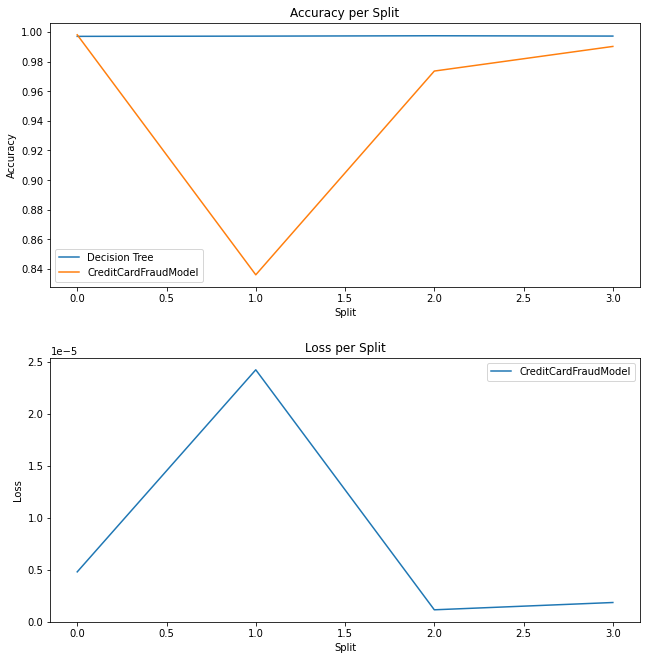

In [ ]:
    
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
fig.tight_layout(pad=5.0)

# Plot accuracy
for name, metric in metrics.items():
    axes[0].plot(metric["accuracy"], label=name)
axes[0].set_title("Accuracy per Split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Plot loss
for name, metric in metrics.items():
    if metric["loss"]:
        axes[1].plot(metric["loss"], label=name)
axes[1].set_title("Loss per Split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.show()